## Get all the imports

In [1]:
import os
import random
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler

torch.manual_seed(27)
random.seed(27)
np.random.seed(27)

sns.set_theme(style="ticks")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Download the dataset and split into train, validation and test

In [4]:
airpassengers_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
data_dir = Path("./data_downloaded")
data_dir.mkdir(parents=True, exist_ok=True)
dataset_path = data_dir / "AirPassengers_fresh.csv"

# Fresh download for this notebook run (no dependency on repository datasets).
df = pd.read_csv(airpassengers_url)
df.to_csv(dataset_path, index=False)

df.columns = ["Month", "#Passengers"]
df["Month"] = pd.to_datetime(df["Month"], format="%Y-%m")

df_train = df.loc[df["Month"].dt.year < 1957].copy()
df_val = df.loc[(df["Month"].dt.year >= 1957) & (df["Month"].dt.year < 1959)].copy()
df_test = df.loc[df["Month"].dt.year >= 1959].copy()

print("Dataset saved to:", dataset_path.as_posix())
print("Training Split with number of samples:", len(df_train))
display(df_train.head())
print("\nValidation Split with number of samples:", len(df_val))
display(df_val.head())
print("\nTest Split with number of samples:", len(df_test))
display(df_test.head())

Dataset saved to: data_downloaded/AirPassengers_fresh.csv
Training Split with number of samples: 96


,Month,#Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121



Validation Split with number of samples: 24


,Month,#Passengers
96,1957-01-01,315
97,1957-02-01,301
98,1957-03-01,356
99,1957-04-01,348
100,1957-05-01,355



Test Split with number of samples: 24


,Month,#Passengers
120,1959-01-01,360
121,1959-02-01,342
122,1959-03-01,406
123,1959-04-01,396
124,1959-05-01,420


In [5]:
# Scale the values appropriately
scaler = MinMaxScaler()

# pandas>=3 enforces dtype safety; cast first so float assignments are valid
df_train = df_train.astype({"#Passengers": "float64"})
df_val = df_val.astype({"#Passengers": "float64"})
df_test = df_test.astype({"#Passengers": "float64"})

df_train.loc[:, "#Passengers"] = scaler.fit_transform(df_train[["#Passengers"]])[:, 0]
df_val.loc[:, "#Passengers"] = scaler.transform(df_val[["#Passengers"]])[:, 0]
df_test.loc[:, "#Passengers"] = scaler.transform(df_test[["#Passengers"]])[:, 0]

## Check out the data trend

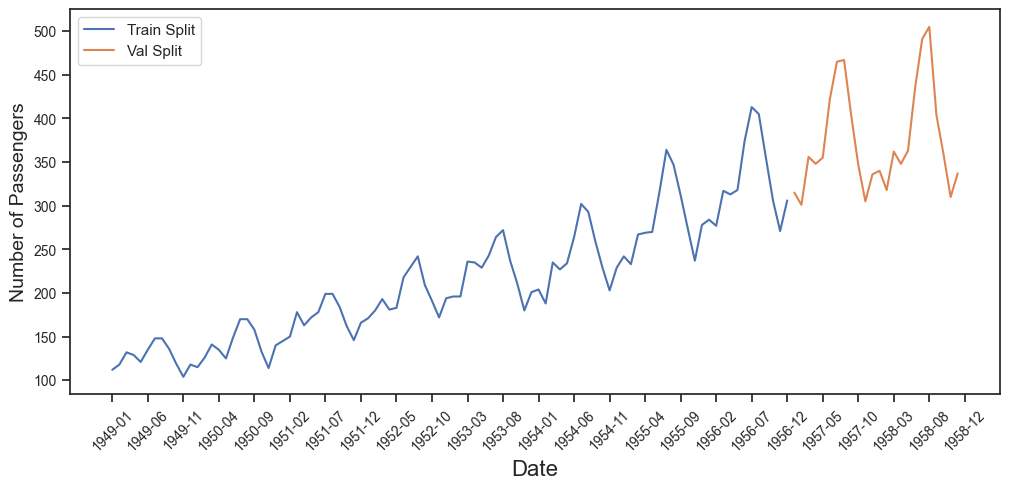

In [6]:
plt.figure(figsize=(12, 5))
sns.lineplot(
    x=np.arange(len(df_train)),
    y=scaler.inverse_transform(df_train[["#Passengers"]])[:, 0],
    label="Train Split"
)
sns.lineplot(
    x=np.arange(len(df_train), len(df_train) + len(df_val)),
    y=scaler.inverse_transform(df_val[["#Passengers"]])[:, 0],
    label="Val Split"
)

train_ticks = [i for idx, i in enumerate(df_train["Month"].dt.strftime("%Y-%m").tolist()) if idx % 5 == 0]
val_ticks = [i for idx, i in enumerate(df_val["Month"].dt.strftime("%Y-%m").tolist()) if (idx + 1) % 5 == 0] + [df_val["Month"].dt.strftime("%Y-%m").tolist()[-1]]
plt.xticks(np.arange(0, len(df_train) + len(df_val) + 1, 5), train_ticks + val_ticks, rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel("Date", fontsize=16)
plt.ylabel("Number of Passengers", fontsize=14)
plt.legend()
plt.show()

## Design the data module responsible for data processing and generating data loaders

In [7]:
class DataModule:
    def __init__(self, window_size, stride, batch_size):
        self.window_size = window_size
        self.stride = stride
        self.batch_size = batch_size

    def convert_data_to_sequence_format(self, data):
        X, Y = list(), list()
        for i in range(0, len(data) - self.window_size, self.stride):
            X.append(data[i:i + self.window_size])
            Y.append(data[i + self.window_size])
        X, Y = np.asarray(X), np.asarray(Y)
        X = np.reshape(X, (X.shape[0], X.shape[1], 1))
        return X, Y

    def data_loader(self, X, Y, shuffle=True):
        dataset = TensorDataset(torch.tensor(X), torch.tensor(Y))
        return DataLoader(dataset, batch_size=self.batch_size, shuffle=shuffle)

## Design a Custom Bidirectional RNN cell

In [8]:
class BiRNNCell(torch.nn.Module):
    def __init__(self, input_size, hidden_size, activation="tanh", bias=True):
        super(BiRNNCell, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.activation = {
            "tanh": torch.nn.Tanh(),
            "sigmoid": torch.nn.Sigmoid(),
            "relu": torch.nn.ReLU(),
        }[activation]

        self.input_layer_forward = torch.nn.Linear(self.input_size, self.hidden_size, bias=bias)
        self.hidden_layer_forward = torch.nn.Linear(self.hidden_size, self.hidden_size, bias=bias)

        self.input_layer_backward = torch.nn.Linear(self.input_size, self.hidden_size, bias=bias)
        self.hidden_layer_backward = torch.nn.Linear(self.hidden_size, self.hidden_size, bias=bias)

    def _run_direction(self, x, reverse=False):
        ht = torch.rand((x.shape[0], self.hidden_size), device=x.device)
        ht = ht / (torch.sqrt(torch.sum(torch.square(ht), dim=0)) + 1e-8)
        output = list()

        indices = range(x.shape[1] - 1, -1, -1) if reverse else range(x.shape[1])
        for i in indices:
            if reverse:
                ht = self.activation(self.input_layer_backward(x[:, i]) + self.hidden_layer_backward(ht))
                output.insert(0, ht)
            else:
                ht = self.activation(self.input_layer_forward(x[:, i]) + self.hidden_layer_forward(ht))
                output.append(ht)

        output = torch.stack(output)
        output = torch.swapdims(output, 0, 1)
        return output

    def forward(self, x):
        forward_output = self._run_direction(x, reverse=False)
        backward_output = self._run_direction(x, reverse=True)
        return torch.cat([forward_output, backward_output], dim=-1)

## Define the Custom Bidirectional RNN model

In [9]:
class CustomBiRNN(torch.nn.Module):
    def __init__(self, num_layers, input_size, hidden_size, activation, bias, device):
        super(CustomBiRNN, self).__init__()
        self.num_layers = num_layers

        self.BiRNN_layers = list()
        for i in range(num_layers):
            if i == 0:
                self.BiRNN_layers.append(BiRNNCell(input_size, hidden_size, activation, bias).to(device))
            else:
                self.BiRNN_layers.append(BiRNNCell(2 * hidden_size, hidden_size, activation, bias).to(device))
        self.BiRNN_layers = torch.nn.Sequential(*self.BiRNN_layers)

        self.linear = torch.nn.Linear(2 * hidden_size, 1)
        self.optimizer = torch.optim.AdamW(self.parameters(), lr=0.001)
        self.criterion = torch.nn.MSELoss()

    def forward(self, x):
        for i in range(self.num_layers):
            x = self.BiRNN_layers[i](x)
        x = self.linear(x[:, -1]).squeeze(-1)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        self.optimizer.zero_grad()
        preds = self.forward(x.float())
        loss = self.criterion(preds, y.float())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)
        self.optimizer.step()
        return loss.item(), preds.detach().cpu().numpy()

    def validation_step(self, batch, batch_idx):
        x, y = batch
        preds = self.forward(x.float())
        loss = self.criterion(preds, y.float())
        return loss.item(), preds.detach().cpu().numpy()

## Get the data loaders

In [11]:
window_size, stride = 24, 1
batch_size = 128 if device.type == "cuda" else 32

data_module = DataModule(window_size, stride, batch_size)

# Build one continuous series, then slice windows for train/val/test targets.
full_series = np.concatenate(
    [
        df_train["#Passengers"].values,
        df_val["#Passengers"].values,
        df_test["#Passengers"].values,
    ],
    axis=0,
 )

X_all, Y_all = data_module.convert_data_to_sequence_format(full_series)

n_train = len(df_train) - window_size
n_val = len(df_val)
n_test = len(df_test)

X_train = X_all[:n_train]
Y_train = Y_all[:n_train]
print("Train data shape:", X_train.shape, Y_train.shape)

X_val = X_all[n_train:n_train + n_val]
Y_val = Y_all[n_train:n_train + n_val]
print("Val data shape:", X_val.shape, Y_val.shape)

X_test = X_all[n_train + n_val:n_train + n_val + n_test]
Y_test = Y_all[n_train + n_val:n_train + n_val + n_test]
print("Test data shape:", X_test.shape, Y_test.shape)

train_data_loader = data_module.data_loader(X_train, Y_train, shuffle=True)
val_data_loader = data_module.data_loader(X_val, Y_val, shuffle=False)
test_data_loader = data_module.data_loader(X_test, Y_test, shuffle=False)

Train data shape: (72, 24, 1) (72,)
Val data shape: (24, 24, 1) (24,)
Test data shape: (24, 24, 1) (24,)


## Perform training and validation with our custom Bidirectional RNN

In [12]:
num_layers = 2
input_size = X_train.shape[-1]
hidden_size = 256 if device.type == "cuda" else 96
num_epochs = 350

model = CustomBiRNN(num_layers, input_size, hidden_size, "tanh", True, device).to(device)

train_epoch_loss = list()
val_epoch_loss = list()
min_val_loss = np.inf

for epoch in tqdm(range(num_epochs), desc="Training Custom BiRNN"):
    train_iter_loss = list()
    model.train()
    for batch_idx, batch in enumerate(train_data_loader):
        batch = (batch[0].to(device), batch[1].to(device))
        loss, _ = model.training_step(batch, batch_idx)
        train_iter_loss.append(loss)
    train_epoch_loss.append(sum(train_iter_loss) / len(train_iter_loss))

    val_iter_loss = list()
    model.eval()
    with torch.no_grad():
        for batch_idx, batch in enumerate(val_data_loader):
            batch = (batch[0].to(device), batch[1].to(device))
            loss, _ = model.validation_step(batch, batch_idx)
            val_iter_loss.append(loss)
    val_epoch_loss.append(sum(val_iter_loss) / len(val_iter_loss))

    if val_epoch_loss[-1] < min_val_loss:
        min_val_loss = val_epoch_loss[-1]
        best_custom_model = deepcopy(model)

print("Best Validation Loss (Custom BiRNN):", min_val_loss)

Training Custom BiRNN: 100%|██████████| 350/350 [00:16<00:00, 21.30it/s]

Best Validation Loss (Custom BiRNN): 0.005135014653205872


## Plot the training and validation losses

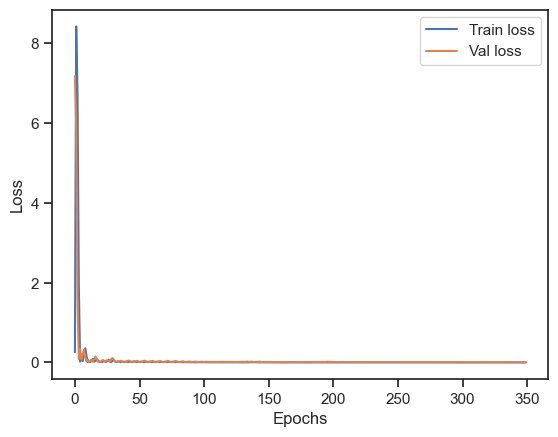

In [13]:
sns.lineplot(x=np.arange(num_epochs), y=train_epoch_loss, label="Train loss")
sns.lineplot(x=np.arange(num_epochs), y=val_epoch_loss, label="Val loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Get all the predictions on the train, validation and test sets

In [14]:
def predict_model(model, data_loader, device):
    model.eval()
    total_predictions = list()
    with torch.no_grad():
        for batch_idx, batch in tqdm(enumerate(data_loader), total=len(data_loader), leave=False):
            batch = (batch[0].to(device), batch[1].to(device))
            _, preds = model.validation_step(batch, batch_idx)
            total_predictions.extend(preds)
    return np.asarray(total_predictions)

train_eval_loader = data_module.data_loader(X_train, Y_train, shuffle=False)
custom_train_predictions = predict_model(best_custom_model, train_eval_loader, device)
custom_val_predictions = predict_model(best_custom_model, val_data_loader, device)
custom_test_predictions = predict_model(best_custom_model, test_data_loader, device)

custom_train_predictions_inv = scaler.inverse_transform(custom_train_predictions.reshape(-1, 1))[:, 0]
custom_val_predictions_inv = scaler.inverse_transform(custom_val_predictions.reshape(-1, 1))[:, 0]
custom_test_predictions_inv = scaler.inverse_transform(custom_test_predictions.reshape(-1, 1))[:, 0]

Y_train_inv = scaler.inverse_transform(Y_train.reshape(-1, 1))[:, 0]
Y_val_inv = scaler.inverse_transform(Y_val.reshape(-1, 1))[:, 0]
Y_test_inv = scaler.inverse_transform(Y_test.reshape(-1, 1))[:, 0]

custom_train_mse = np.mean(np.square(custom_train_predictions_inv - Y_train_inv))
custom_val_mse = np.mean(np.square(custom_val_predictions_inv - Y_val_inv))
custom_test_mse = np.mean(np.square(custom_test_predictions_inv - Y_test_inv))

print("Custom BiRNN Training MSE:", custom_train_mse)
print("Custom BiRNN Validation MSE:", custom_val_mse)
print("Custom BiRNN Test MSE:", custom_test_mse)

Custom BiRNN Training MSE: 46.73608842597524
Custom BiRNN Validation MSE: 549.3913948420281
Custom BiRNN Test MSE: 6236.002445720526


## Plot the ground truth and Custom BiRNN predictions

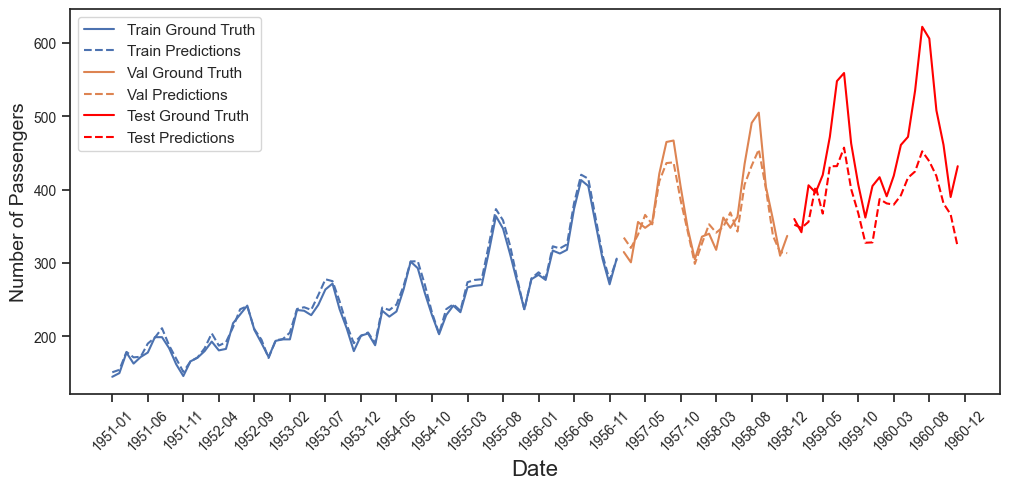

In [15]:
plt.figure(figsize=(12, 5))

y_train_plot = scaler.inverse_transform(df_train[["#Passengers"]].iloc[window_size:])[:, 0]
sns.lineplot(x=np.arange(len(y_train_plot)), y=y_train_plot, label="Train Ground Truth", color="#4c72b0")
sns.lineplot(x=np.arange(len(y_train_plot)), y=custom_train_predictions_inv, label="Train Predictions", color="#4c72b0", linestyle="--")

y_val_plot = scaler.inverse_transform(df_val[["#Passengers"]])[:, 0]
sns.lineplot(
    x=np.arange(len(y_train_plot), len(y_train_plot) + len(df_val)),
    y=y_val_plot,
    label="Val Ground Truth",
    color="#dd8452"
)
sns.lineplot(
    x=np.arange(len(y_train_plot), len(y_train_plot) + len(df_val)),
    y=custom_val_predictions_inv,
    label="Val Predictions",
    color="#dd8452",
    linestyle="--"
)

y_test_plot = scaler.inverse_transform(df_test[["#Passengers"]])[:, 0]
sns.lineplot(
    x=np.arange(len(y_train_plot) + len(df_val), len(y_train_plot) + len(df_val) + len(df_test)),
    y=y_test_plot,
    label="Test Ground Truth",
    color="red"
)
sns.lineplot(
    x=np.arange(len(y_train_plot) + len(df_val), len(y_train_plot) + len(df_val) + len(df_test)),
    y=custom_test_predictions_inv,
    label="Test Predictions",
    color="red",
    linestyle="--"
)

train_ticks = [i for idx, i in enumerate(df_train["Month"].dt.strftime("%Y-%m").tolist()[window_size:]) if idx % 5 == 0]
val_ticks = [i for idx, i in enumerate(df_val["Month"].dt.strftime("%Y-%m").tolist()) if (idx + 1) % 5 == 0] + [df_val["Month"].dt.strftime("%Y-%m").tolist()[-1]]
test_ticks = [i for idx, i in enumerate(df_test["Month"].dt.strftime("%Y-%m").tolist()) if (idx + 1) % 5 == 0] + [df_test["Month"].dt.strftime("%Y-%m").tolist()[-1]]
plt.xticks(np.arange(0, len(y_train_plot) + len(df_val) + len(df_test) + 1, 5), train_ticks + val_ticks + test_ticks, rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel("Date", fontsize=16)
plt.ylabel("Number of Passengers", fontsize=14)
plt.legend()
plt.show()

## Define the PyTorch Bidirectional RNN model

In [16]:
class PyTorchBiRNN(torch.nn.Module):
    def __init__(self, num_layers, input_size, hidden_size, activation, bias, device):
        super(PyTorchBiRNN, self).__init__()
        self.RNN = torch.nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            nonlinearity=activation,
            bias=bias,
            batch_first=True,
            bidirectional=True,
            dropout=0.15 if num_layers > 1 else 0.0,
            device=device
        )

        self.linear = torch.nn.Linear(2 * hidden_size, 1)
        self.optimizer = torch.optim.AdamW(self.parameters(), lr=0.001)
        self.criterion = torch.nn.MSELoss()

    def forward(self, x):
        num_directions = 2
        h0 = torch.rand((self.RNN.num_layers * num_directions, x.shape[0], self.RNN.hidden_size), device=x.device)
        h0 = h0 / (torch.sqrt(torch.sum(torch.square(h0), dim=0)) + 1e-8)
        x, _ = self.RNN(x, h0)
        x = self.linear(x[:, -1]).squeeze(-1)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        self.optimizer.zero_grad()
        preds = self.forward(x.float())
        loss = self.criterion(preds, y.float())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)
        self.optimizer.step()
        return loss.item(), preds.detach().cpu().numpy()

    def validation_step(self, batch, batch_idx):
        x, y = batch
        preds = self.forward(x.float())
        loss = self.criterion(preds, y.float())
        return loss.item(), preds.detach().cpu().numpy()

## Perform training and validation using PyTorch Bidirectional RNN

In [17]:
pt_model = PyTorchBiRNN(num_layers, input_size, hidden_size, "tanh", True, device).to(device)

pt_train_epoch_loss = list()
pt_val_epoch_loss = list()
pt_min_val_loss = np.inf

for epoch in tqdm(range(num_epochs), desc="Training PyTorch BiRNN"):
    train_iter_loss = list()
    pt_model.train()
    for batch_idx, batch in enumerate(train_data_loader):
        batch = (batch[0].to(device), batch[1].to(device))
        loss, _ = pt_model.training_step(batch, batch_idx)
        train_iter_loss.append(loss)
    pt_train_epoch_loss.append(sum(train_iter_loss) / len(train_iter_loss))

    val_iter_loss = list()
    pt_model.eval()
    with torch.no_grad():
        for batch_idx, batch in enumerate(val_data_loader):
            batch = (batch[0].to(device), batch[1].to(device))
            loss, _ = pt_model.validation_step(batch, batch_idx)
            val_iter_loss.append(loss)
    pt_val_epoch_loss.append(sum(val_iter_loss) / len(val_iter_loss))

    if pt_val_epoch_loss[-1] < pt_min_val_loss:
        pt_min_val_loss = pt_val_epoch_loss[-1]
        best_pt_model = deepcopy(pt_model)

print("Best Validation Loss (PyTorch BiRNN):", pt_min_val_loss)

Training PyTorch BiRNN: 100%|██████████| 350/350 [00:02<00:00, 155.90it/s]

Best Validation Loss (PyTorch BiRNN): 0.0028072684071958065


## Plot the training and validation losses

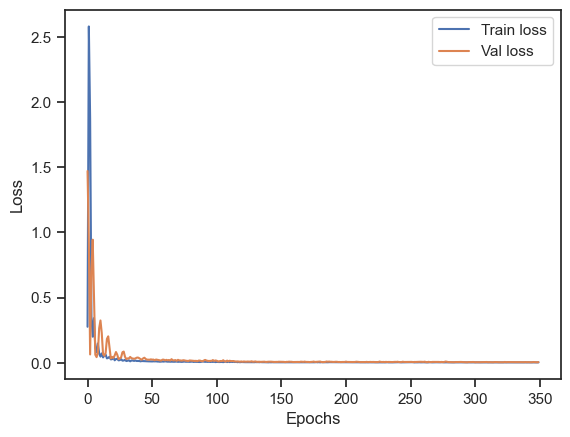

In [18]:
sns.lineplot(x=np.arange(num_epochs), y=pt_train_epoch_loss, label="Train loss")
sns.lineplot(x=np.arange(num_epochs), y=pt_val_epoch_loss, label="Val loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Evaluate PyTorch Bidirectional RNN and compare both models

  0%|          | 0/1 [00:00<?, ?it/s]f:\PhD Stuff\DL Lab\.venv\Lib\site-packages\torch\nn\modules\rnn.py:728: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1480.)
  result = _VF.rnn_tanh(
                                     

PyTorch BiRNN Training MSE: 151.89453407311032
PyTorch BiRNN Validation MSE: 293.28370009153167
PyTorch BiRNN Test MSE: 723.1595492477072


,Metric,Custom BiRNN,PyTorch BiRNN
0,Train MSE,46.736088,151.894534
1,Validation MSE,549.391395,293.283700
2,Test MSE,6236.002446,723.159549


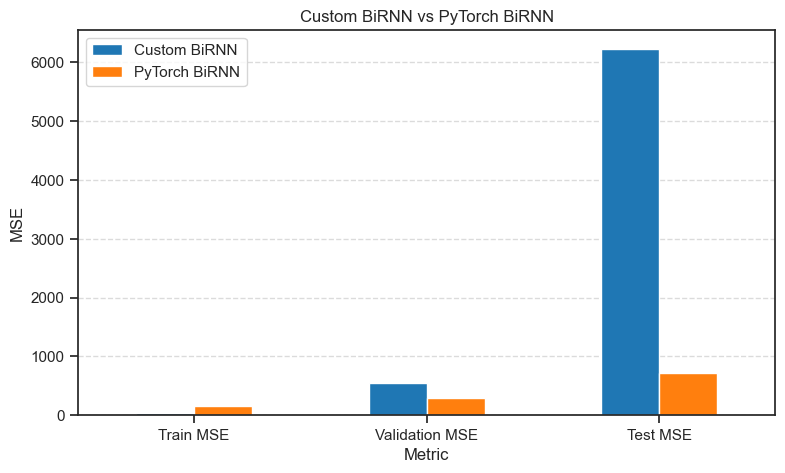

In [19]:
pt_train_predictions = predict_model(best_pt_model, train_eval_loader, device)
pt_val_predictions = predict_model(best_pt_model, val_data_loader, device)
pt_test_predictions = predict_model(best_pt_model, test_data_loader, device)

pt_train_predictions_inv = scaler.inverse_transform(pt_train_predictions.reshape(-1, 1))[:, 0]
pt_val_predictions_inv = scaler.inverse_transform(pt_val_predictions.reshape(-1, 1))[:, 0]
pt_test_predictions_inv = scaler.inverse_transform(pt_test_predictions.reshape(-1, 1))[:, 0]

pt_train_mse = np.mean(np.square(pt_train_predictions_inv - Y_train_inv))
pt_val_mse = np.mean(np.square(pt_val_predictions_inv - Y_val_inv))
pt_test_mse = np.mean(np.square(pt_test_predictions_inv - Y_test_inv))

print("PyTorch BiRNN Training MSE:", pt_train_mse)
print("PyTorch BiRNN Validation MSE:", pt_val_mse)
print("PyTorch BiRNN Test MSE:", pt_test_mse)

comparison_df = pd.DataFrame({
    "Metric": ["Train MSE", "Validation MSE", "Test MSE"],
    "Custom BiRNN": [custom_train_mse, custom_val_mse, custom_test_mse],
    "PyTorch BiRNN": [pt_train_mse, pt_val_mse, pt_test_mse]
})

display(comparison_df)

comparison_df.set_index("Metric").plot(kind="bar", figsize=(9, 5), color=["#1f77b4", "#ff7f0e"])
plt.title("Custom BiRNN vs PyTorch BiRNN")
plt.ylabel("MSE")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=0)
plt.show()